*Copyright (c) Recommenders contributors.*

*Licensed under the MIT License.*

# Wide and Deep Model for Movie Recommendation (PyTorch)

<br>

A linear model with a wide set of crossed-column (co-occurrence) features can memorize the feature interactions, while deep neural networks (DNN) can generalize the feature patterns through low-dimensional dense embeddings learned for the sparse features. [**Wide and Deep**](https://arxiv.org/abs/1606.07792) learning jointly trains wide linear model and deep neural networks to combine the benefits of memorization and generalization for recommender systems.

<img src="https://raw.githubusercontent.com/recommenders-team/resources/main/images/wide_and_deep.png" width=800 style="display:block; margin-left:auto; margin-right:auto;">


This notebook shows how to build and test the wide-and-deep model using PyTorch. With the [movie recommendation dataset](https://grouplens.org/datasets/movielens/), we quickly demonstrate following topics:
1. How to prepare data
2. Build the model
3. Train with periodic evaluation
4. Test the model and export

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import sys
import math
import logging
import sklearn
import pandas as pd
import torch

from recommenders.utils.constants import (
    DEFAULT_USER_COL as USER_COL,
    DEFAULT_ITEM_COL as ITEM_COL,
    DEFAULT_RATING_COL as RATING_COL,
    DEFAULT_PREDICTION_COL as PREDICT_COL,
    DEFAULT_GENRE_COL as ITEM_FEAT_COL,
    SEED
)
from recommenders.utils import plot
from recommenders.datasets import movielens
from recommenders.datasets.pandas_df_utils import user_item_pairs
from recommenders.datasets.python_splitters import python_random_split
from recommenders.evaluation.python_evaluation import (
    rmse,
    mae,
    ndcg_at_k,
    precision_at_k,
)
from recommenders.models.wide_deep.wide_deep_utils import WideDeepModel
from recommenders.utils.notebook_utils import store_metadata

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

print(f"System version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

System version: 3.11.14 (main, Jan 14 2026, 19:35:32) [Clang 21.1.4 ]
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090 Laptop GPU


In [3]:
# Parameters

# Recommend top k items
TOP_K = 10
# Select MovieLens data size: 100k, 1m, 10m, or 20m
MOVIELENS_DATA_SIZE = "100k"
# Use periodic evaluation during training
EVALUATE_WHILE_TRAINING = True

# Train and test set pickle file paths. If provided, use them. Otherwise, download the MovieLens dataset.
DATA_DIR = None
TRAIN_PICKLE_PATH = None
TEST_PICKLE_PATH = None
EXPORT_DIR_BASE = os.path.join("outputs", "model")

#### Hyperparameters
MODEL_TYPE = "wide_deep"
N_EPOCHS = 20  # Number of training epochs
BATCH_SIZE = 32
# Wide (linear) model hyperparameters
LINEAR_OPTIMIZER = "adagrad"
LINEAR_OPTIMIZER_LR = 0.0621  # Learning rate
# DNN model hyperparameters
DNN_OPTIMIZER = "adadelta"
DNN_OPTIMIZER_LR = 0.1
# Layer dimensions. Set 0 to skip a layer.
DNN_HIDDEN_LAYER_1 = 0
DNN_HIDDEN_LAYER_2 = 64
DNN_HIDDEN_LAYER_3 = 128
DNN_HIDDEN_LAYER_4 = 512
DNN_HIDDEN_UNITS = [h for h in [DNN_HIDDEN_LAYER_1, DNN_HIDDEN_LAYER_2, DNN_HIDDEN_LAYER_3, DNN_HIDDEN_LAYER_4] if h > 0]
DNN_USER_DIM = 32          # User embedding feature dimension
DNN_ITEM_DIM = 16          # Item embedding feature dimension
DNN_DROPOUT = 0.8
DNN_BATCH_NORM = 1         # 1 to use batch normalization, 0 if not.

### 1. Prepare Data

#### 1.1 Movie Rating and Genres Data
First, download [MovieLens](https://grouplens.org/datasets/movielens/) data. Movies in the data set are tagged as one or more genres where there are total 19 genres including '*unknown*'. We load *movie genres* to use them as item features.

In [4]:
use_preset = (TRAIN_PICKLE_PATH is not None and TEST_PICKLE_PATH is not None)
if not use_preset:
    # The genres of each movie are returned as '|' separated string, e.g. "Animation|Children's|Comedy".
    data = movielens.load_pandas_df(
        size=MOVIELENS_DATA_SIZE,
        header=[USER_COL, ITEM_COL, RATING_COL],
        genres_col=ITEM_FEAT_COL
    )
    display(data.head())

INFO:recommenders.datasets.download_utils:Downloading http://files.grouplens.org/datasets/movielens/ml-100k.zip
100%|██████████| 4.81k/4.81k [00:01<00:00, 3.56kKB/s]


,userID,itemID,rating,genre
0,196,242,3.0,Comedy
1,186,302,3.0,Crime|Film-Noir|Mystery|Thriller
2,22,377,1.0,Children's|Comedy
3,244,51,2.0,Drama|Romance|War|Western
4,166,346,1.0,Crime|Drama


#### 1.2 Encode Item Features (Genres)
To use genres from our model, we multi-hot-encode them with scikit-learn's [MultiLabelBinarizer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html).

For example, *Movie id=2355* has three genres, *Animation|Children's|Comedy*, which are being converted into an integer array of the indicator value for each genre like `[0, 0, 1, 1, 1, 0, 0, 0, ...]`. In the later step, we convert this into a float array and feed into the model.

> For faster feature encoding, you may load ratings and items separately (by using `movielens.load_item_df`), encode the item-features, then combine the rating and item dataframes by using join-operation.

In [5]:
if not use_preset and ITEM_FEAT_COL is not None:
    # Encode 'genres' into int array (multi-hot representation) to use as item features
    genres_encoder = sklearn.preprocessing.MultiLabelBinarizer()
    data[ITEM_FEAT_COL] = genres_encoder.fit_transform(
        data[ITEM_FEAT_COL].apply(lambda s: s.split("|"))
    ).tolist()
    print("Genres:", genres_encoder.classes_)
    display(data.head())

Genres: ['Action' 'Adventure' 'Animation' "Children's" 'Comedy' 'Crime'
 'Documentary' 'Drama' 'Fantasy' 'Film-Noir' 'Horror' 'Musical' 'Mystery'
 'Romance' 'Sci-Fi' 'Thriller' 'War' 'Western' 'unknown']


,userID,itemID,rating,genre
0,196,242,3.0,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,186,302,3.0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, ..."
2,22,377,1.0,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,244,51,2.0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ..."
4,166,346,1.0,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."


#### 1.3 Train and Test Split

In [6]:
if not use_preset:
    train, test = python_random_split(data, ratio=0.75, seed=SEED)
else:
    train = pd.read_pickle(path=TRAIN_PICKLE_PATH if DATA_DIR is None else os.path.join(DATA_DIR, TRAIN_PICKLE_PATH))
    test = pd.read_pickle(path=TEST_PICKLE_PATH if DATA_DIR is None else os.path.join(DATA_DIR, TEST_PICKLE_PATH))
    data = pd.concat([train, test])

print(f"{len(train)} train samples and {len(test)} test samples")

75000 train samples and 25000 test samples


In [7]:
# Unique items in the dataset
if ITEM_FEAT_COL is None:
    items = data.drop_duplicates(ITEM_COL)[[ITEM_COL]].reset_index(drop=True)
    item_feat_shape = None
else:
    items = data.drop_duplicates(ITEM_COL)[[ITEM_COL, ITEM_FEAT_COL]].reset_index(drop=True)
    item_feat_shape = len(items[ITEM_FEAT_COL][0])
# Unique users in the dataset
users = data.drop_duplicates(USER_COL)[[USER_COL]].reset_index(drop=True)

print(f"Total {len(items)} items and {len(users)} users in the dataset")

Total 1682 items and 943 users in the dataset


### 2. Build Model

Wide-and-deep model consists of a linear model and DNN. We use the following hyperparameters and feature sets for the model:

<br> | <div align="center">Wide (linear) model</div> | <div align="center">Deep neural networks</div>
---|---|---
Feature set | <ul><li>User-item co-occurrence features<br>to capture how their co-occurrence<br>correlates with the target rating</li></ul> | <ul><li>Deep, lower-dimensional embedding vectors<br>for every user and item</li><li>Item feature vector</li></ul>
Hyperparameters | <ul><li>Adagrad optimizer</li><li>Learning rate = 0.0621</li></ul> | <ul><li>Adadelta optimizer</li><li>Learning rate = 0.1</li><li>Hidden units = [64, 128, 512]</li><li>Dropout rate = 0.8</li><li>Use batch normalization (Batch size = 32)</li><li>User embedding vector size = 32</li><li>Item embedding vector size = 16</li></ul>

In [8]:
# Build the model
model = WideDeepModel(
    users=users[USER_COL].values,
    items=items[ITEM_COL].values,
    model_type=MODEL_TYPE,
    crossed_feat_dim=1000,
    user_dim=DNN_USER_DIM,
    item_dim=DNN_ITEM_DIM,
    item_feat_shape=item_feat_shape,
    item_feat_col=ITEM_FEAT_COL,
    dnn_hidden_units=DNN_HIDDEN_UNITS,
    dnn_dropout=DNN_DROPOUT,
    dnn_batch_norm=(DNN_BATCH_NORM == 1),
    user_col=USER_COL,
    item_col=ITEM_COL,
    seed=SEED,
)
print(model)

WideDeepModel(
  (wide_user): Embedding(943, 1)
  (wide_item): Embedding(1682, 1)
  (wide_cross): Embedding(1000, 1)
  (deep_user): Embedding(943, 32, max_norm=5.656854249492381)
  (deep_item): Embedding(1682, 16, max_norm=4.0)
  (dnn): Sequential(
    (0): Linear(in_features=67, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.8, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.8, inplace=False)
    (8): Linear(in_features=128, out_features=512, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.8, inplace=False)
    (12): Linear(in_features=512, out_features=1, bias=True)
  )
)


### 3. Train and Evaluate Model

Now we are all set to train the model. Here, we show how to utilize an evaluation callback to track model performance while training. The callback estimates the model performance on the given data based on the specified evaluation functions. Note we pass the test set to evaluate the model on rating metrics while we use the ranking-pool (all user-item pairs) for ranking metrics.

> Note: The loss is Mean Squared Error. Square root of the loss is the same as [RMSE](https://en.wikipedia.org/wiki/Root-mean-square_deviation).

In [9]:
cols = {
    "col_user": USER_COL,
    "col_item": ITEM_COL,
    "col_rating": RATING_COL,
    "col_prediction": PREDICT_COL,
}

# Prepare ranking evaluation set, i.e. get the cross join of all user-item pairs
ranking_pool = user_item_pairs(
    user_df=users,
    item_df=items,
    user_col=USER_COL,
    item_col=ITEM_COL,
    user_item_filter_df=train,  # Remove seen items
    shuffle=True,
    seed=SEED
)

# Create checkpoint frequency
save_checkpoints_epochs = max(1, N_EPOCHS // 5)

# Prepare evaluation logger
eval_log = {}

def evaluation_callback(m, epoch):
    """Evaluate the model on rating and ranking metrics."""
    # Rating metrics
    test_no_label = test.drop(RATING_COL, axis=1)
    preds = m.predict(test_no_label)
    pred_df = test_no_label.copy()
    pred_df[PREDICT_COL] = preds
    for name, result in [
        ("rmse", rmse(test, pred_df, **cols)),
        ("mae", mae(test, pred_df, **cols)),
    ]:
        eval_log.setdefault(name, []).append(result)
        logger.info("Epoch %d - %s: %.4f", epoch, name, result)

    # Ranking metrics
    preds = m.predict(ranking_pool)
    pred_df = ranking_pool.copy()
    pred_df[PREDICT_COL] = preds
    for name, result in [
        ("ndcg_at_k", ndcg_at_k(test, pred_df, **cols, k=TOP_K)),
        ("precision_at_k", precision_at_k(test, pred_df, **cols, k=TOP_K)),
    ]:
        eval_log.setdefault(name, []).append(result)
        logger.info("Epoch %d - %s: %.4f", epoch, name, result)

Let's train the model.

In [10]:
%%time
print(f"Training epochs = {N_EPOCHS}, Batch size = {BATCH_SIZE}")

model.fit(
    train_df=train,
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    y_col=RATING_COL,
    wide_optimizer=LINEAR_OPTIMIZER,
    wide_optimizer_lr=LINEAR_OPTIMIZER_LR,
    deep_optimizer=DNN_OPTIMIZER,
    deep_optimizer_lr=DNN_OPTIMIZER_LR,
    seed=SEED,
    eval_fn=evaluation_callback if EVALUATE_WHILE_TRAINING else None,
    eval_every_n_epochs=save_checkpoints_epochs if EVALUATE_WHILE_TRAINING else None,
)

Training epochs = 20, Batch size = 32


INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 1/20 – loss = 2.8091
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 2/20 – loss = 1.3644
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 3/20 – loss = 1.0518
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 4/20 – loss = 0.9378
INFO:root:Epoch 4 - rmse: 0.9638
INFO:root:Epoch 4 - mae: 0.7702
INFO:root:Epoch 4 - ndcg_at_k: 0.1588
INFO:root:Epoch 4 - precision_at_k: 0.1399
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 5/20 – loss = 0.8963
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 6/20 – loss = 0.8780
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 7/20 – loss = 0.8672
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 8/20 – loss = 0.8608
INFO:root:Epoch 8 - rmse: 0.9525
INFO:root:Epoch 8 - mae: 0.7563
INFO:root:Epoch 8 - ndcg_at_k: 0.1283
INFO:root:Epoch 8 - precision_at_k: 0.1169
INFO:recommenders.models.wide_deep.wide_deep_utils:Epoch 9/20 – loss = 0.8548
INFO:r

CPU times: user 8min 58s, sys: 1min 25s, total: 10min 23s
Wall time: 10min 5s


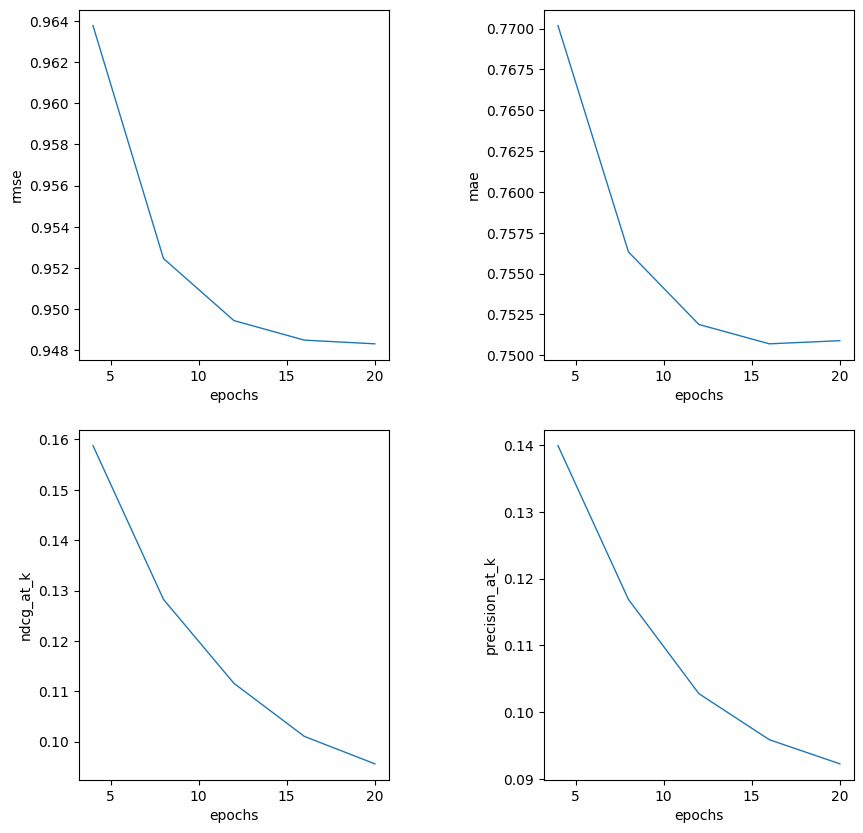

In [11]:
if EVALUATE_WHILE_TRAINING and eval_log:
    for i, (m_name, values) in enumerate(eval_log.items(), 1):
        store_metadata(f"eval_{m_name}", values)
        x = [save_checkpoints_epochs * j for j in range(1, len(values) + 1)]
        plot.line_graph(
            values=list(zip(values, x)),
            labels=m_name,
            x_name="epochs",
            y_name=m_name,
            subplot=(math.ceil(len(eval_log) / 2), 2, i),
        )

### 4. Test and Export Model

#### 4.1 Item rating prediction

In [12]:
predictions = model.predict(test)
prediction_df = test.drop(RATING_COL, axis=1)
prediction_df[PREDICT_COL] = predictions

rating_rmse = rmse(test, prediction_df, **cols)
rating_mae = mae(test, prediction_df, **cols)
print(f"RMSE: {rating_rmse:.4f}")
print(f"MAE:  {rating_mae:.4f}")

RMSE: 0.9483
MAE:  0.7509


#### 4.2 Recommend k items
For top-k recommendation evaluation, we use `recommend_k_items()` which scores all user-item pairs, removes items the user has already seen in the training set, and returns the top-k items per user.

In [13]:
top_k_df = model.recommend_k_items(test, top_k=TOP_K, remove_seen=True)

ranking_ndcg = ndcg_at_k(test, top_k_df, **cols, k=TOP_K)
ranking_precision = precision_at_k(test, top_k_df, **cols, k=TOP_K)
print(f"NDCG@{TOP_K}:      {ranking_ndcg:.4f}")
print(f"Precision@{TOP_K}: {ranking_precision:.4f}")

NDCG@10:      0.0956
Precision@10: 0.0923


#### 4.3 Export Model
Finally, we export the model so that we can load later for re-training, evaluation, and prediction.

In [14]:
os.makedirs(EXPORT_DIR_BASE, exist_ok=True)
export_path = os.path.join(EXPORT_DIR_BASE, "wide_deep_model.pt")
torch.save(model.state_dict(), export_path)
print("Model exported to", export_path)

Model exported to outputs/model/wide_deep_model.pt


In [15]:
# Record results for tests - ignore this cell
store_metadata("rmse", rating_rmse)
store_metadata("mae", rating_mae)
store_metadata("ndcg_at_k", ranking_ndcg)
store_metadata("precision_at_k", ranking_precision)
store_metadata("saved_model_dir", export_path)
